<a href="https://colab.research.google.com/github/dbellavista-ai/internship-deepfake-forensic/blob/main/step3_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q grad-cam timm

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_curve, auc
import timm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 44.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Extract the dataset ONLY if it hasn't been extracted in this session
dataset_dest_path = '/content/dataset'

if not os.path.exists(dataset_dest_path):
    print("Extracting the dataset... (this might take a few minutes)")
    !unzip -q /content/drive/MyDrive/internship-deepfake-forensic/deepfake_dataset.zip -d {dataset_dest_path}
    print("Extraction completed!")
else:
    print("Dataset already present and ready to use!")

Mounted at /content/drive
Extracting the dataset... (this might take a few minutes)
Extraction completed!


In [ ]:
class DeepfakeDataset(Dataset):
    def __init__(self, real_dirs, fake_dirs, transform=None):
        self.filepaths, self.labels = [], []
        self.transform = transform
        for d in real_dirs:
            for ext in ('*.png', '*.jpg', '*.jpeg'):
                paths = glob.glob(os.path.join(d, ext))
                self.filepaths.extend(paths)
                self.labels.extend([0] * len(paths))
        for d in fake_dirs:
            for ext in ('*.png', '*.jpg', '*.jpeg'):
                paths = glob.glob(os.path.join(d, ext))
                self.filepaths.extend(paths)
                self.labels.extend([1] * len(paths))

    def __len__(self): return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor([self.labels[idx]], dtype=torch.float32)


test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
class StandardEfficientNet(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        self.model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)

class DeiT_Discriminator(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        self.model = timm.create_model('deit_tiny_patch16_224', pretrained=True)
        n_features = self.model.head.in_features
        self.model.head = nn.Linear(n_features, num_classes)

    def forward(self, x):
        return self.model(x)

class HybridDeepfakeDiscriminator(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT).features
        in_channels = 1280
        self.attention = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 8, 1, bias=False),
            nn.BatchNorm2d(in_channels // 8), nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 8, in_channels, 1, bias=False), nn.Sigmoid()
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4), nn.Linear(in_channels, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=0.4), nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        features = features * self.attention(features)
        return self.classifier(torch.flatten(self.pool(features), 1))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

path_baseline = '/content/drive/MyDrive/internship-deepfake-forensic/deepfake_models/baseline'
path_retrain  = '/content/drive/MyDrive/internship-deepfake-forensic/deepfake_models/retrain'
BATCH = 32

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

ts_reals_p1 = ['/content/dataset/FEI_Split_Intra/test/original/', '/content/dataset/F++_Split_Intra/source_based/test/original/']
ts_fakes_p1 = ['/content/dataset/FEI_Split_Intra/test/fake/', '/content/dataset/F++_Split_Intra/source_based/test/fake/']

ts_reals_p2 = ['/content/dataset/FEI_Split_Intra/test/original/', '/content/dataset/F++_Split_Intra/target_based/test/original/']
ts_fakes_p2 = ['/content/dataset/FEI_Split_Intra/test/fake/', '/content/dataset/F++_Split_Intra/target_based/test/fake/']

# Test Dataloaders
test_loader_p1 = DataLoader(DeepfakeDataset(ts_reals_p1, ts_fakes_p1, test_transforms), BATCH, shuffle=False)
test_loader_p2 = DataLoader(DeepfakeDataset(ts_reals_p2, ts_fakes_p2, test_transforms), BATCH, shuffle=False)

Device in use: cpu


In [ ]:
print("Loading Models for Direct Comparison...")

#Standard EfficientNet-B0
model_std_p1_base = StandardEfficientNet().to(device)
model_std_p1_base.load_state_dict(torch.load(os.path.join(path_baseline, "std_b0_P1_source_intra_step1.pth"), map_location=device))

model_std_p1_adv = StandardEfficientNet().to(device)
model_std_p1_adv.load_state_dict(torch.load(os.path.join(path_retrain, "std_b0_P1_source_intra_step2.pth"), map_location=device))

#Deit-Tiny
model_deit_p1_base = DeiT_Discriminator().to(device)
model_deit_p1_base.load_state_dict(torch.load(os.path.join(path_baseline, "deit_P1_source_intra_step1.pth"), map_location=device))

model_deit_p1_adv = DeiT_Discriminator().to(device)
model_deit_p1_adv.load_state_dict(torch.load(os.path.join(path_retrain, "deit_P1_source_intra_step2.pth"), map_location=device))

#Hybrid EfficientNet-B0
model_hyb_p1_base = HybridDeepfakeDiscriminator().to(device)
model_hyb_p1_base.load_state_dict(torch.load(os.path.join(path_baseline, "hyb_b0_P1_source_intra_step1.pth"), map_location=device))

model_hyb_p1_adv = HybridDeepfakeDiscriminator().to(device)
model_hyb_p1_adv.load_state_dict(torch.load(os.path.join(path_retrain, "hyb_b0_P1_source_intra_step2.pth"), map_location=device))

models_p1 = {
    "Std EfficientNet-B0 (Step 1)": model_std_p1_base,
    "Std EfficientNet-B0 (Step 2)": model_std_p1_adv,
    "Deit-Tiny (Step 1)": model_deit_p1_base,
    "Deit-Tiny (Step 2)": model_deit_p1_adv,
    "Hyb EfficientNet-B0 (Step 1)": model_hyb_p1_base,
    "Hyb EfficientNet-B0 (Step 2)": model_hyb_p1_adv,
}

#Standard EfficientNet-B0
model_std_p2_base = StandardEfficientNet().to(device)
model_std_p2_base.load_state_dict(torch.load(os.path.join(path_baseline, "std_b0_P2_target_intra_step1.pth"), map_location=device))

model_std_p2_adv = StandardEfficientNet().to(device)
model_std_p2_adv.load_state_dict(torch.load(os.path.join(path_retrain, "std_b0_P2_target_intra_step2.pth"), map_location=device))

#Deit-Tiny
model_deit_p2_base = DeiT_Discriminator().to(device)
model_deit_p2_base.load_state_dict(torch.load(os.path.join(path_baseline, "deit_P2_target_intra_step1.pth"), map_location=device))

model_deit_p2_adv = DeiT_Discriminator().to(device)
model_deit_p2_adv.load_state_dict(torch.load(os.path.join(path_retrain, "deit_P2_target_intra_step2.pth"), map_location=device))

#Hybrid EfficientNet-B0
model_hyb_p2_base = HybridDeepfakeDiscriminator().to(device)
model_hyb_p2_base.load_state_dict(torch.load(os.path.join(path_baseline, "hyb_b0_P2_target_intra_step1.pth"), map_location=device))

model_hyb_p2_adv = HybridDeepfakeDiscriminator().to(device)
model_hyb_p2_adv.load_state_dict(torch.load(os.path.join(path_retrain, "hyb_b0_P2_target_intra_step2.pth"), map_location=device))

models_p2 = {
    "Std EfficientNet-B0 (Step 1)": model_std_p2_base,
    "Std EfficientNet-B0 (Step 2)": model_std_p2_adv,
    "Deit-Tiny (Step 1)": model_deit_p2_base,
    "Deit-Tiny (Step 2)": model_deit_p2_adv,
    "Hyb EfficientNet-B0 (Step 1)": model_hyb_p2_base,
    "Hyb EfficientNet-B0 (Step 2)": model_hyb_p2_adv,
}

print("Models loaded and ready for the showdown!")

Loading Models for Direct Comparison...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s] 
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Models loaded and ready for the showdown!


In [ ]:
def get_all_predictions(model, loader, device):
    model.eval()
    all_labels, all_probs, all_preds = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images).view(-1)

            probs = torch.sigmoid(outputs)
            preds = (outputs > 0.0).float()

            all_labels.extend(labels.view(-1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    return np.array(all_labels), np.array(all_probs), np.array(all_preds)


def plot_final_evaluation(models_dict, loader, device, phase_name):
    print(f"\nStarting Quantitative Test for: {phase_name}")

    num_models = len(models_dict)
    fig, axes = plt.subplots(1, num_models + 1, figsize=(6 * (num_models + 1), 6))
    fig.suptitle(f"Quantitative Results - {phase_name}", fontsize=20, fontweight='bold')

    ax_roc = axes[-1]
    ax_roc.plot([0, 1], [0, 1], 'k--', label='Random')

    colors = ['#aec7e8', '#1f77b4', '#ffbb78', '#ff7f0e', '#98df8a', '#2ca02c']

    for i, (name, model) in enumerate(models_dict.items()):
        y_true, y_probs, y_preds = get_all_predictions(model, loader, device)

        # Metrics
        acc = accuracy_score(y_true, y_preds)
        f1 = f1_score(y_true, y_preds)
        prec = precision_score(y_true, y_preds)
        rec = recall_score(y_true, y_preds)

        print(f"[{name}] Acc: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(y_true, y_preds)
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=axes[i],
            cbar=False,
            xticklabels=['REAL', 'FAKE'],
            yticklabels=['REAL', 'FAKE']
        )

        axes[i].set_title(f"{name}")
        if i == 0:
            axes[i].set_ylabel('Ground Truth')
        axes[i].set_xlabel('Predicted')

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_true, y_probs)
        roc_auc = auc(fpr, tpr)

        ax_roc.plot(
            fpr,
            tpr,
            color=colors[i],
            lw=2.5,
            label=f"{name} (AUC: {roc_auc:.4f})"
        )

    ax_roc.set_title("ROC Curves")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend(loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.show()


Starting Quantitative Test for: Phase 1: Baseline vs Advanced
[Std EfficientNet-B0 (Step 1)] Acc: 0.8370 | F1: 0.8993 | Prec: 0.9645 | Rec: 0.8424
[Std EfficientNet-B0 (Step 2)] Acc: 0.8636 | F1: 0.9180 | Prec: 0.9552 | Rec: 0.8836
[Deit-Tiny (Step 1)] Acc: 0.5723 | F1: 0.6754 | Prec: 0.9816 | Rec: 0.5148
[Deit-Tiny (Step 2)] Acc: 0.7315 | F1: 0.8214 | Prec: 0.9660 | Rec: 0.7145
[Hyb EfficientNet-B0 (Step 1)] Acc: 0.7962 | F1: 0.8696 | Prec: 0.9726 | Rec: 0.7864
[Hyb EfficientNet-B0 (Step 2)] Acc: 0.8425 | F1: 0.9037 | Prec: 0.9589 | Rec: 0.8544


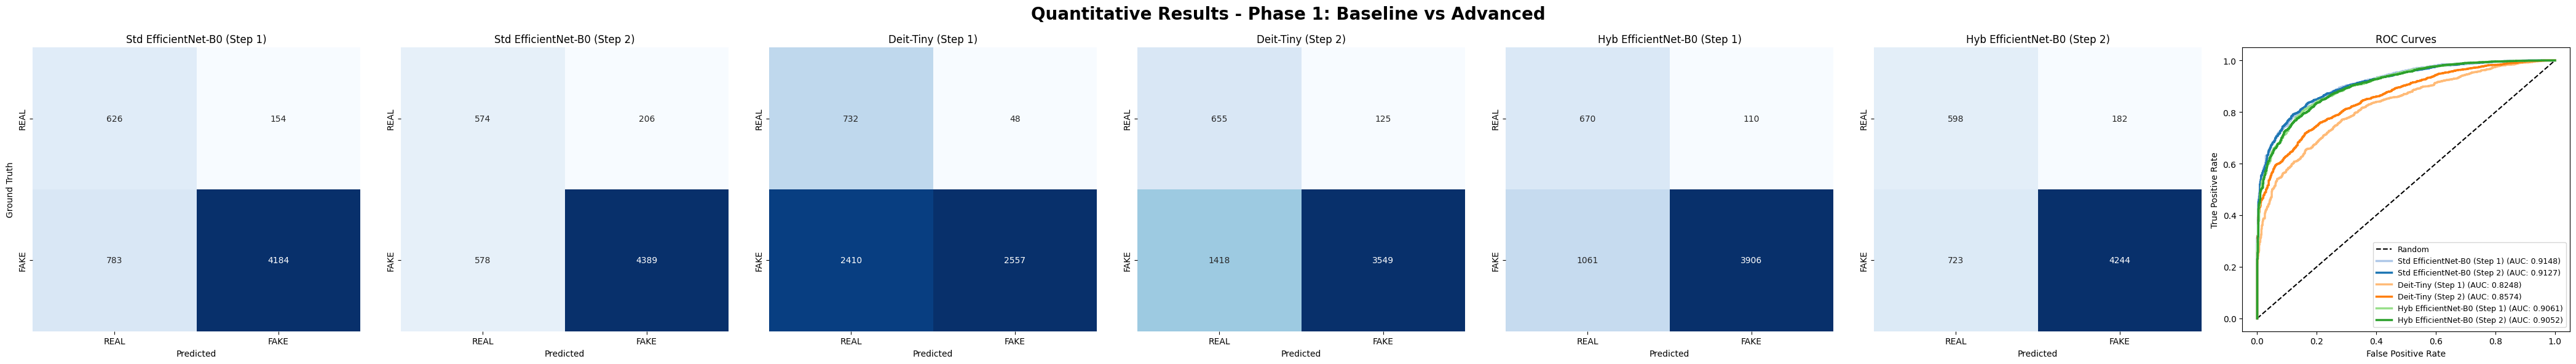


Starting Quantitative Test for: Phase 2: Baseline vs Advanced
[Std EfficientNet-B0 (Step 1)] Acc: 0.8856 | F1: 0.9304 | Prec: 0.9835 | Rec: 0.8827
[Std EfficientNet-B0 (Step 2)] Acc: 0.9029 | F1: 0.9420 | Prec: 0.9762 | Rec: 0.9100
[Deit-Tiny (Step 1)] Acc: 0.8054 | F1: 0.8775 | Prec: 0.9653 | Rec: 0.8042
[Deit-Tiny (Step 2)] Acc: 0.8907 | F1: 0.9349 | Prec: 0.9662 | Rec: 0.9055
[Hyb EfficientNet-B0 (Step 1)] Acc: 0.8826 | F1: 0.9283 | Prec: 0.9860 | Rec: 0.8770
[Hyb EfficientNet-B0 (Step 2)] Acc: 0.9193 | F1: 0.9525 | Prec: 0.9716 | Rec: 0.9342


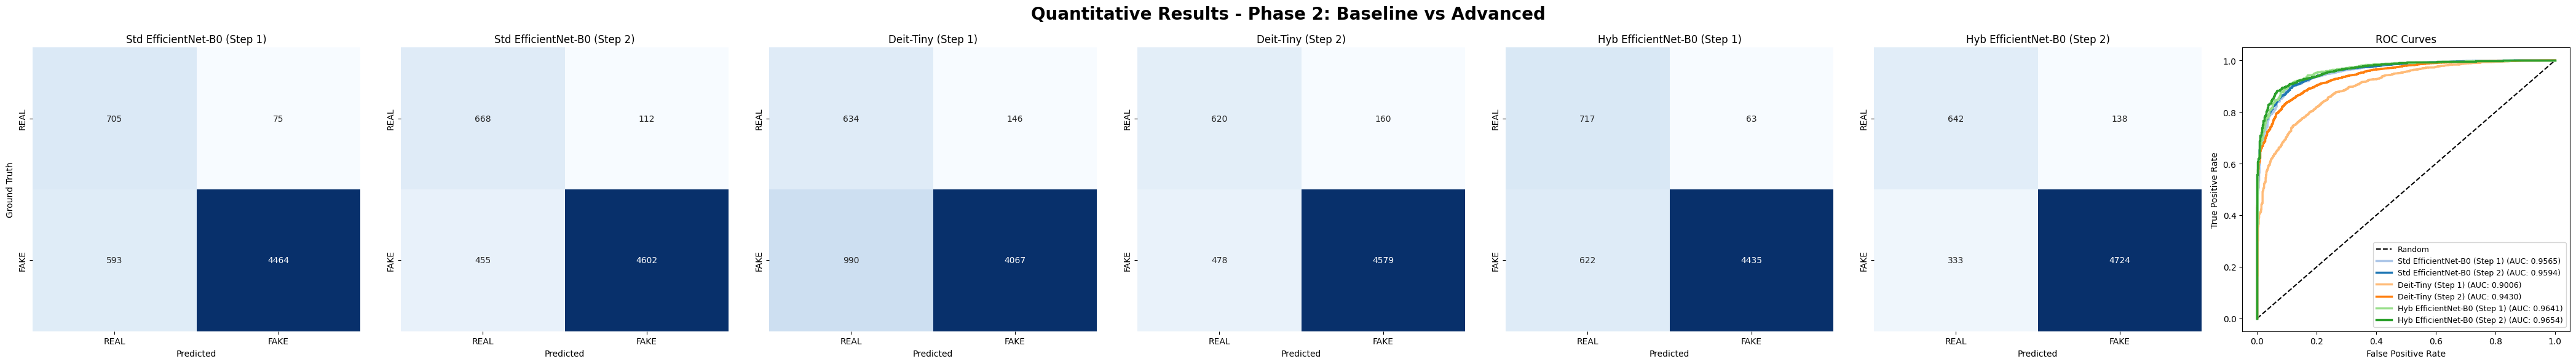

In [ ]:
plot_final_evaluation(models_p1, test_loader_p1, device, "Phase 1: Baseline vs Advanced")
plot_final_evaluation(models_p2, test_loader_p2, device, "Phase 2: Baseline vs Advanced")

In [ ]:

print("--- STARTING CROSS-DATASET EVALUATION ON CELEB-DF V3 ---")

celeb_reals = ['/content/dataset/CelebDF_Test/original/']
celeb_fakes = ['/content/dataset/CelebDF_Test/fake/']

test_loader_celeb = DataLoader(DeepfakeDataset(celeb_reals, celeb_fakes, test_transforms), batch_size=BATCH, shuffle=False)


--- STARTING CROSS-DATASET EVALUATION ON CELEB-DF V3 ---



Starting Quantitative Test for: Cross-Dataset: P1 Models on Celeb-DF
[Std EfficientNet-B0 (Step 1)] Acc: 0.6730 | F1: 0.6191 | Prec: 0.7414 | Rec: 0.5315
[Std EfficientNet-B0 (Step 2)] Acc: 0.6657 | F1: 0.6284 | Prec: 0.7075 | Rec: 0.5652
[Deit-Tiny (Step 1)] Acc: 0.5219 | F1: 0.1903 | Prec: 0.6211 | Rec: 0.1124
[Deit-Tiny (Step 2)] Acc: 0.5854 | F1: 0.4973 | Prec: 0.6315 | Rec: 0.4101
[Hyb EfficientNet-B0 (Step 1)] Acc: 0.6848 | F1: 0.6207 | Prec: 0.7793 | Rec: 0.5157
[Hyb EfficientNet-B0 (Step 2)] Acc: 0.6910 | F1: 0.6687 | Prec: 0.7208 | Rec: 0.6236


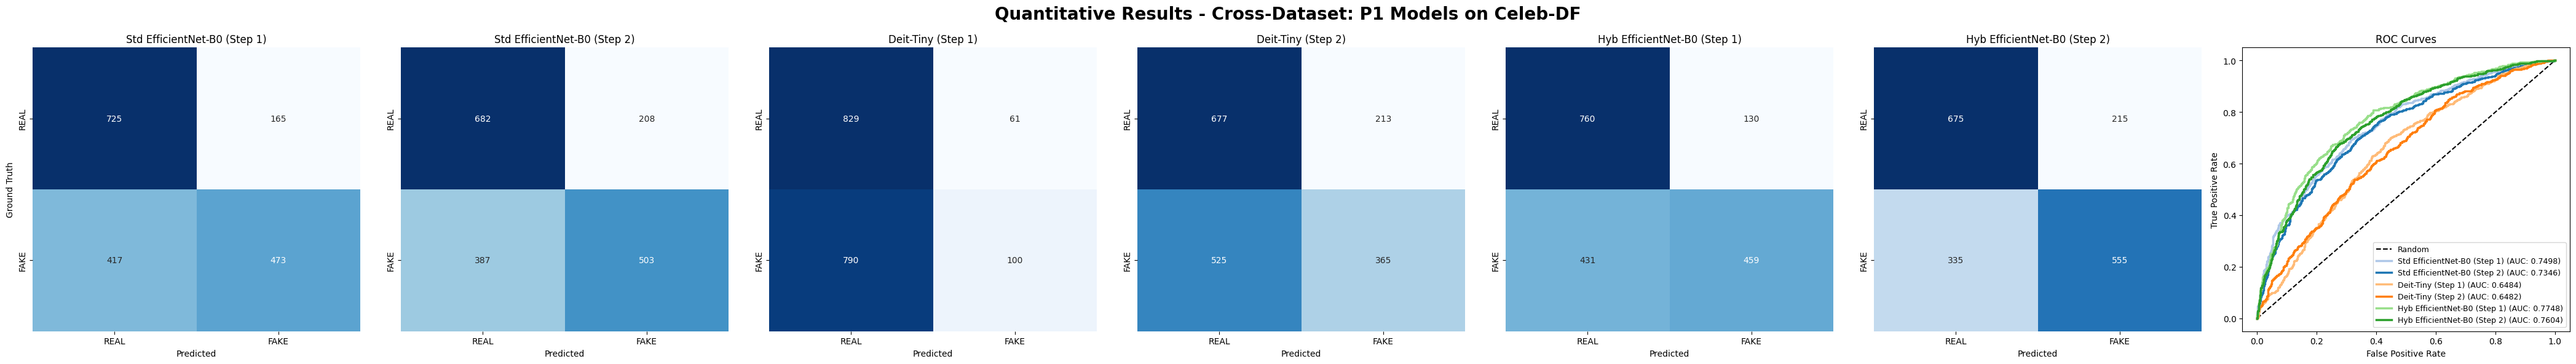


Starting Quantitative Test for: Cross-Dataset: P2 Models on Celeb-DF
[Std EfficientNet-B0 (Step 1)] Acc: 0.6607 | F1: 0.5770 | Prec: 0.7658 | Rec: 0.4629
[Std EfficientNet-B0 (Step 2)] Acc: 0.6393 | F1: 0.5591 | Prec: 0.7191 | Rec: 0.4573
[Deit-Tiny (Step 1)] Acc: 0.5399 | F1: 0.5269 | Prec: 0.5422 | Rec: 0.5124
[Deit-Tiny (Step 2)] Acc: 0.6455 | F1: 0.6413 | Prec: 0.6490 | Rec: 0.6337
[Hyb EfficientNet-B0 (Step 1)] Acc: 0.6444 | F1: 0.5074 | Prec: 0.8253 | Rec: 0.3663
[Hyb EfficientNet-B0 (Step 2)] Acc: 0.6517 | F1: 0.6021 | Prec: 0.7021 | Rec: 0.5270


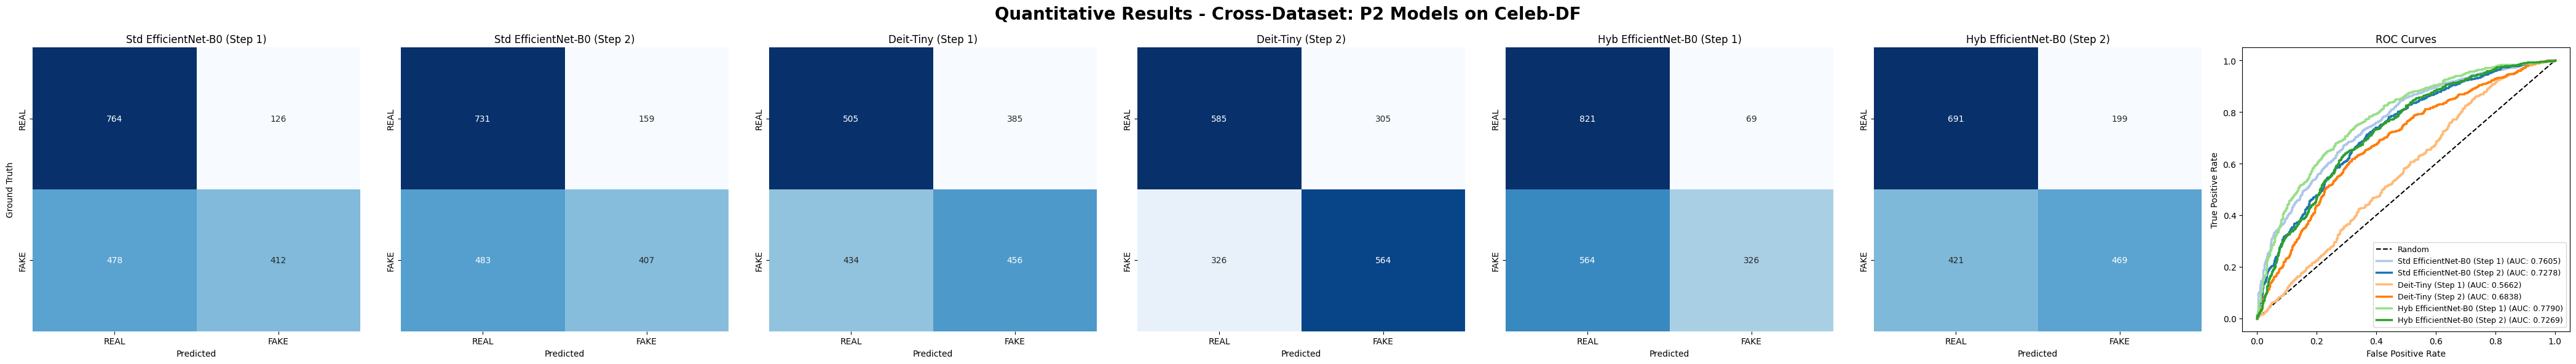

In [ ]:
plot_final_evaluation(models_p1, test_loader_celeb, device, "Cross-Dataset: P1 Models on Celeb-DF")
plot_final_evaluation(models_p2, test_loader_celeb, device, "Cross-Dataset: P2 Models on Celeb-DF")